# Manual exploration of the datasets created by gpt5.2 and gemini

### init

In [1]:
import sys
from datasets import load_dataset,concatenate_datasets
new_path = r'/home/creux/Documents/AI/VTikz/VariabilityBenchmark'
sys.path.append(new_path)

ds1 = load_dataset("CharlyR/vtikz-evaluation", "simpleLLM_benchmark_openaigpt5.2_pk_1_t_0.7_v1.61",split="tikz")
ds2 = load_dataset("CharlyR/vtikz-evaluation", "simpleLLM_benchmark_googlegemini3propreview_pk_1_t_0.7_v1.61",split="tikz")
ds = concatenate_datasets([ds1,ds2])
df =ds.to_pandas()


/home/creux/miniconda3/envs/varbench/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
any(metric==100 for metric in df["TemplateMetric"][0][0])

True

In [3]:
import numpy as np
df = df[df["TemplateMetric"].apply(
    lambda metrics: all(len(metric) > 0 and metric[0] != 100 for metric in metrics)
)]

In [4]:
from IPython.display import HTML, display
import base64

def display_images_row(*img_jsons, max_height=300, margin=10):
    imgs = []
    for img in img_jsons:
        if img is None:
            continue
        b64 = base64.b64encode(img["bytes"]).decode("utf-8")
        imgs.append(
            f"<img src='data:image/png;base64,{b64}' "
            f"style='max-height:{max_height}px; margin-right:{margin}px;'>"
        )
    html = "<div style='display:flex; align-items:center;'>" + "".join(imgs) + "</div>"
    display(HTML(html))



In [5]:
import difflib

def single_patch(input: str, prediction: str) -> str:
    """Generates a patch from the given input(which will be splitted) and the prediction"""
    solution_split = prediction.splitlines()
    input_split = input.splitlines()
    current_diff = "\n".join(
        list(difflib.unified_diff(input_split, solution_split, n=0))[2:]
    )
    return current_diff


### Explore

In [ ]:
i=  100

#62
#i at 59 right solution wtf code

i-=  1

Add a third force F3 between F2 and F1, and the corresponding annotations.
flex_third_force



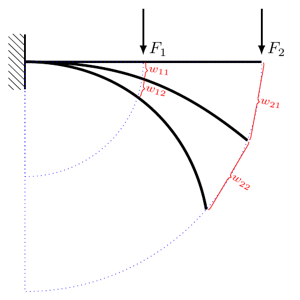
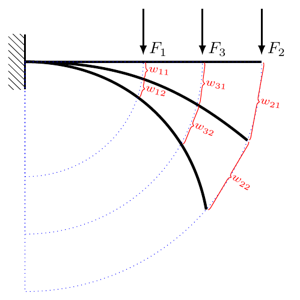
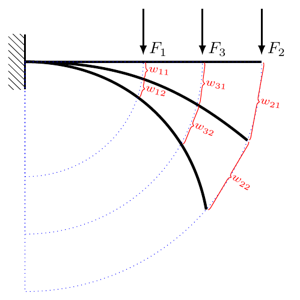

@@ -24,0 +25 @@

+\point{inter}{3.75}{0};
@@ -28,0 +30 @@

+\load{1}{inter}[90];
@@ -30,0 +33 @@

+\notation{1}{inter}{$F_3$};
@@ -36,0 +40 @@

+\draw [arcs,name path=arc3] (begin) -- (inter) arc (0 : -90 : 3.75) -- cycle;
@@ -40 +44,3 @@

-name intersections={of=defl40 and arc1,by={,D2}}];
+name intersections={of=defl40 and arc1,by={,D2}},
+name intersections={of=defl20 and arc3,by={,D3}},
+name intersections={of=defl40 and arc3,by={,D4}}];
@@ -42,0 +49,2 @@

+\inscription{inter}{D3}{$w_{31}$}
+\inscription{D3}{D4}{$w_{32}$}


In [25]:
i+=1
row = df.iloc[i]
print(row["instruction"])
print(row["id"])
display_images_row(
    row["image_input"],
    row["image_solution"][0],
    row["images_result"][0],
)
open("pred.tex","w").write(row["predictions"][0])
d1 =single_patch(row["code"],row["predictions"][0])
print(d1)

In [26]:
d2=single_patch(row["code"],row["template_solution_code"][0])
print(d2)


@@ -24,0 +25 @@

+\point{§def(tquarter)}{3.75}{0};
@@ -28,0 +30 @@

+\load{1}{tquarter}[90];
@@ -30,0 +33 @@

+\notation{1}{tquarter}{$F_3$};
@@ -36,0 +40 @@

+\draw [arcs,name path=arc2] (begin) -- (tquarter) arc (0 : -90 : 3.75) -- cycle;
@@ -39,0 +44,2 @@

+name intersections={of=defl20 and arc2,by={,D3}},
+name intersections={of=defl40 and arc2,by={,D4}},
@@ -42,0 +49,2 @@

+\inscription{tquarter}{D3}{$w_{31}$}
+\inscription{D3}{D4}{$w_{32}$}


In [36]:
from vtikz.evaluation.template import template_valid,create_default
from vtikz.dataset_workflow.utils import uncomment_code,unify_code
path = "/home/creux/Documents/AI/VTikz/VariabilityBenchmark/dataset/tikz/benchmark/flex_third_force/solutions/solution2.tex"

th_fil = unify_code(uncomment_code((open(path).read())))
template_valid(th_fil,row["predictions"][0])

False

In [34]:
print(single_patch(row["predictions"][0],th_fil))

@@ -25 +25 @@

-\point{inter}{3.75}{0};
+\point{§def(tquarter)}{3.75}{0};
@@ -30 +30 @@

-\load{1}{inter}[90];
+\load{1}{tquarter}[90];
@@ -33 +33 @@

-\notation{1}{inter}{$F_3$};
+\notation{1}{tquarter}{$F_3$};
@@ -40 +40 @@

-\draw [arcs,name path=arc3] (begin) -- (inter) arc (0 : -90 : 3.75) -- cycle;
+\draw [arcs,name path=arc3] (begin) -- (tquarter) arc (0 : -90 : 3.75) -- cycle;
@@ -49 +49 @@

-\inscription{inter}{D3}{$w_{31}$}
+\inscription{tquarter}{D3}{$w_{31}$}


In [124]:

[open(f"solution{i}.tex","w").write(template) for i,template in enumerate(row["template_solution_code"])]

[template_valid(template,row["predictions"][0]) for template in row["template_solution_code"]]

[False, False]

In [170]:
print(single_patch(th_fil,row["predictions"][0]))


@@ -1 +1 @@

-\documentclass[tikz,border=2pt]{standalone}
+\documentclass[tikz,border=5]{standalone}
@@ -7 +7 @@

-\definecolor{§def(lust)}{rgb}{§range(0,0.6,0.13), §rangei(0.9,0.1), §range(0,0.6,0.13)}
+\definecolor{lust}{rgb}{0.0, 0.8, 0.0}


In [116]:
i

87

In [158]:
len(df)

123